# **Signal Processing Assignment 3**

In [1]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import pyart
from datetime import datetime
from matplotlib import rc

# plotting set up
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=15)
rc('figure', facecolor='white')


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



### <u>Question 1</u>: 

### Using only H data for all questions, select gates (i.e., specific ranges and azimuth angles) for (1) typical weather, (2) clutter, and (3) the tornado and plot the corresponding I/Q time series. Now estimate the ACF using xcorr for each case and plot the ACF versus lag. Compare the ACF to the I/Q data for each case and describe the results and the differences among the cases.

Read in I/Q file

In [2]:
dfile = "/Users/robbyfrost/Documents/Classes/Radar_Theory/SP3/KTLX_230226_032905181_02.mat"
ds = loadmat(dfile)
tplot = "20230227_" + dfile[-16:-10]
tplot = datetime.strptime(tplot, "%Y%m%d_%H%S%M")

Set arrays

In [3]:
Xh = ds['X_h']
Xv = ds['X_v']
num_pulses = int(ds['num_pulses'][0,0])
rmin = float(ds['r_min'][0,0])
delr = float(ds['delr'][0,0])
rmax = rmin + delr*Xh.shape[1]
ZDRcal = ds['ZDRcal']

powh_lin = np.real(np.nanmean(Xh[:,:,1:num_pulses] * np.conj(Xh[:,:,1:num_pulses]), axis=2))
powh = 10 * np.log10(powh_lin)
powv_lin = np.real(np.nanmean(Xv[:,:,1:num_pulses] * np.conj(Xv[:,:,1:num_pulses]), axis=2))
powv_lin = powv_lin
powv = 10 * np.log10(powv_lin) - ZDRcal

r = np.arange(rmin, rmax, delr)
az = ds['az_set'][0,:]

x = r[:,np.newaxis].dot(np.sin(np.deg2rad(az[np.newaxis,:]))).T
y = r[:,np.newaxis].dot(np.cos(np.deg2rad(az[np.newaxis,:]))).T

Select gate for weather, clutter, and clear-air

In [4]:
# weather echo
xw, yw = -5*1e3, -8*1e3
rw = np.sqrt(xw**2 + yw**2)
rw_idx = np.argmin(np.abs(r-rw))
azw = np.rad2deg(np.arctan2(xw,yw)) % 360
azw_idx = np.argmin(np.abs(az-azw))
# clutter echo
xc, yc = 7*1e3, 0
rc = np.sqrt(xc**2 + yc**2)
rc_idx = np.argmin(np.abs(r-rc))
azc = np.rad2deg(np.arctan2(xc,yc)) % 360
azc_idx = np.argmin(np.abs(az-azc))
# clear-air echo
xca, yca = 75*1e3, -25*1e3
rca = np.sqrt(xca**2 + yca**2)
rca_idx = np.argmin(np.abs(r-rca))
azca = np.rad2deg(np.arctan2(xca,yca)) % 360
azca_idx = np.argmin(np.abs(az-azca))

I/Q data for each echo

In [5]:
# full I/Q arrays
I = np.real(Xh)
Q = np.imag(Xh)
# PRT
prt = ds['pri'][0,0]
# time during volume
time = np.arange(0,num_pulses)*prt

# weather gate I/Q time series
Iw = I[azw_idx,rw_idx]
Qw = Q[azw_idx,rw_idx]
Xhw = Xh[azw_idx,rw_idx]
# clutter gate I/Q time series
Ic = I[azc_idx,rc_idx]
Qc = Q[azc_idx,rc_idx]
Xhc = Xh[azc_idx,rc_idx]
# clear-air gate I/Q time series
Ica = I[azca_idx,rca_idx]
Qca = Q[azca_idx,rca_idx]
Xhca = Xh[azca_idx,rca_idx]

I/Q time series of each echo

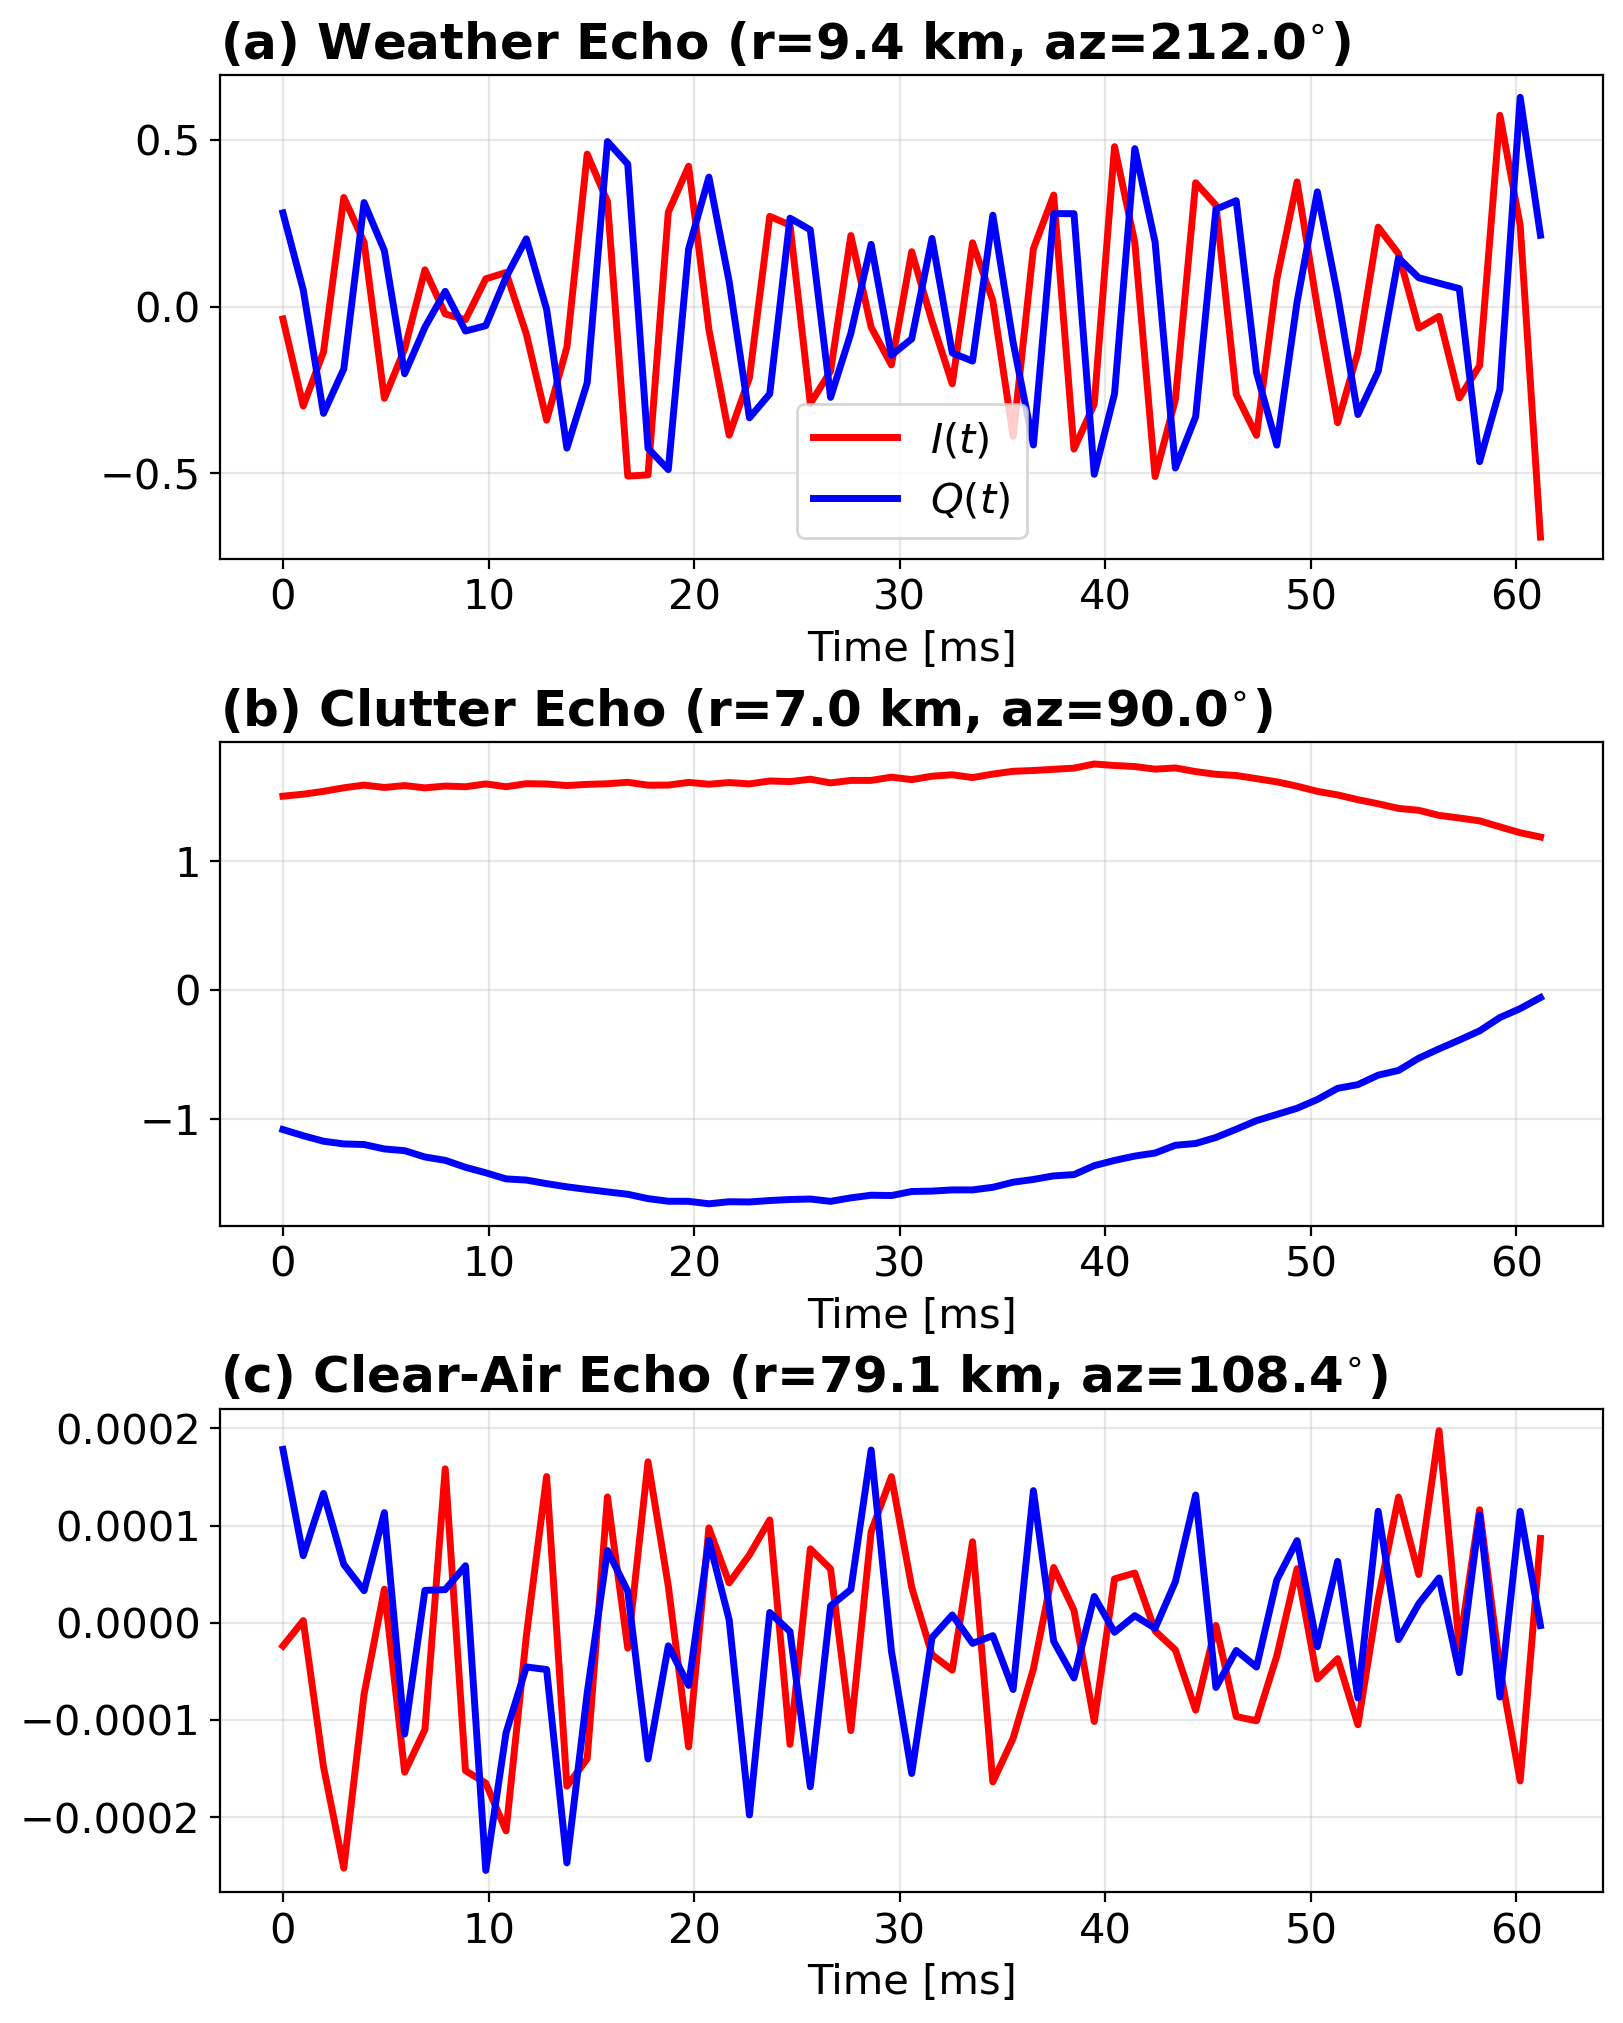

In [6]:
fig, axs = plt.subplots(figsize=(8,10),
                       ncols=1,
                       nrows=3,
                       constrained_layout=True,
                       dpi=200)

# weather
ax = axs[0]
ax.plot(time*1e3, Iw, c='red', label='$I(t)$', lw=2.5)
ax.plot(time*1e3, Qw, c='blue', label="$Q(t)$", lw=2.5)
ax.legend()
ax.set_title(f"(a) Weather Echo (r={(rw/1e3):.1f} km, az={azw:.1f}$^{{\\circ}}$)", 
             fontweight='bold', loc='left')
# clutter
ax = axs[1]
ax.plot(time*1e3, Ic, c='red', lw=2.5)
ax.plot(time*1e3, Qc, c='blue', lw=2.5)
ax.set_title(f"(b) Clutter Echo (r={(rc/1e3):.1f} km, az={azc:.1f}$^{{\\circ}}$)",
             fontweight='bold', loc='left')
# clear-air
ax = axs[2]
ax.plot(time*1e3, Ica, c='red', lw=2.5)
ax.plot(time*1e3, Qca, c='blue', lw=2.5)
ax.set_title(f"(c) Clear-Air Echo (r={(rca/1e3):.1f} km, az={azca:.1f}$^{{\\circ}}$)", 
             fontweight='bold', loc='left')

# clean up
for ax in axs:
    ax.set_xlabel("Time [ms]")
    ax.grid(alpha=0.3)

Estimate autocorrelation function (ACF)

In [7]:
# weather ACF
ACFw = np.correlate(Xhw, Xhw, mode='full')
# clutter ACF
ACFc = np.correlate(Xhc, Xhc, mode='full')
# clear-air ACF
ACFca = np.correlate(Xhca, Xhca, mode='full')

# lags
lags = np.arange(-len(Xhw) + 1, len(Xhw))

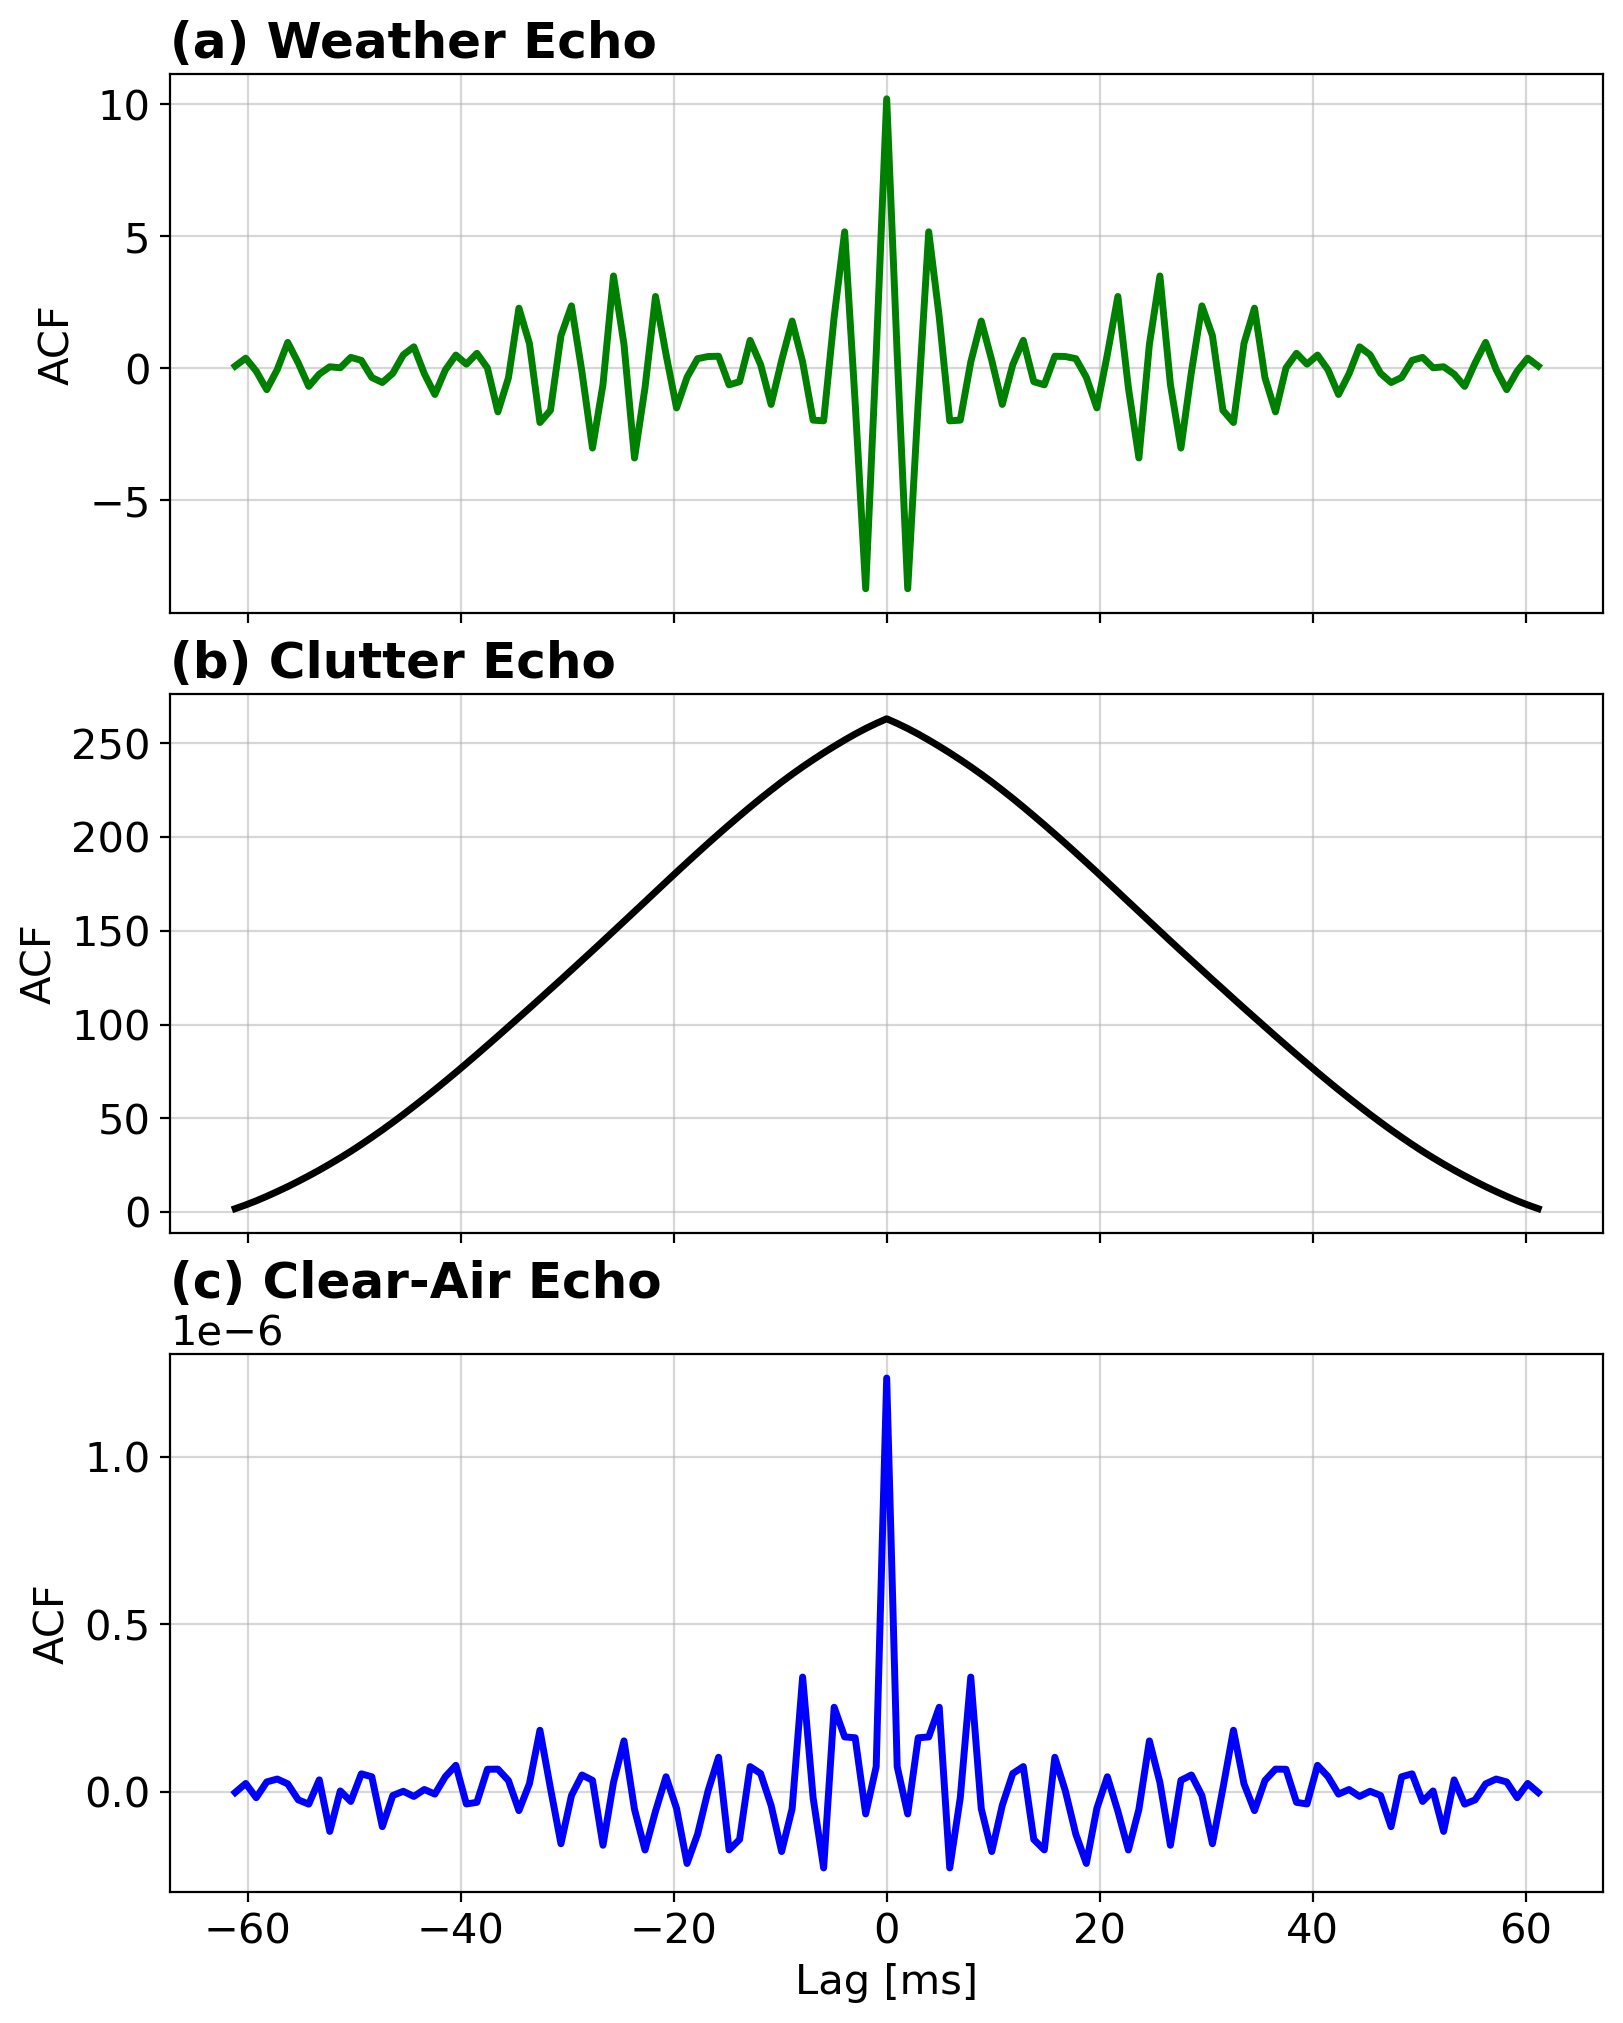

In [8]:
fig, axs = plt.subplots(figsize=(8,10),
                        constrained_layout=True,
                        nrows=3,
                        dpi=200,
                        sharex=True)

# weather
ax = axs[0]
ax.plot(lags*prt*1e3, ACFw,
        c='green',
        lw=2.5)
ax.set_title("(a) Weather Echo", fontweight='bold', loc='left')
# clutter
ax = axs[1]
ax.plot(lags*prt*1e3, ACFc,
        c='black',
        lw=2.5)
ax.set_title("(b) Clutter Echo", fontweight='bold', loc='left')
# clear-air
ax = axs[2]
ax.plot(lags*prt*1e3, ACFca,
        c='blue',
        lw=2.5)
ax.set_title("(c) Clear-Air Echo", fontweight='bold', loc='left')
ax.set_xlabel("Lag [ms]")
for ax in axs:
    ax.grid(alpha=0.5)
    ax.set_ylabel("ACF")

### <u>Question 2</u>:

### Normalize the ACF to a maximum value of 1 and define the decorrelation time as the lag beyond which the normalized ACF drops below 0.8. What is the decorrelation time for each case? Which case has the fastest/slowest decorrelation rate? Why?

In [9]:
# normalize ACF
ACFw_norm = ACFw / np.max(np.real(ACFw))
ACFc_norm = ACFc / np.max(np.real(ACFc))
ACFca_norm = ACFca / np.max(np.real(ACFca))

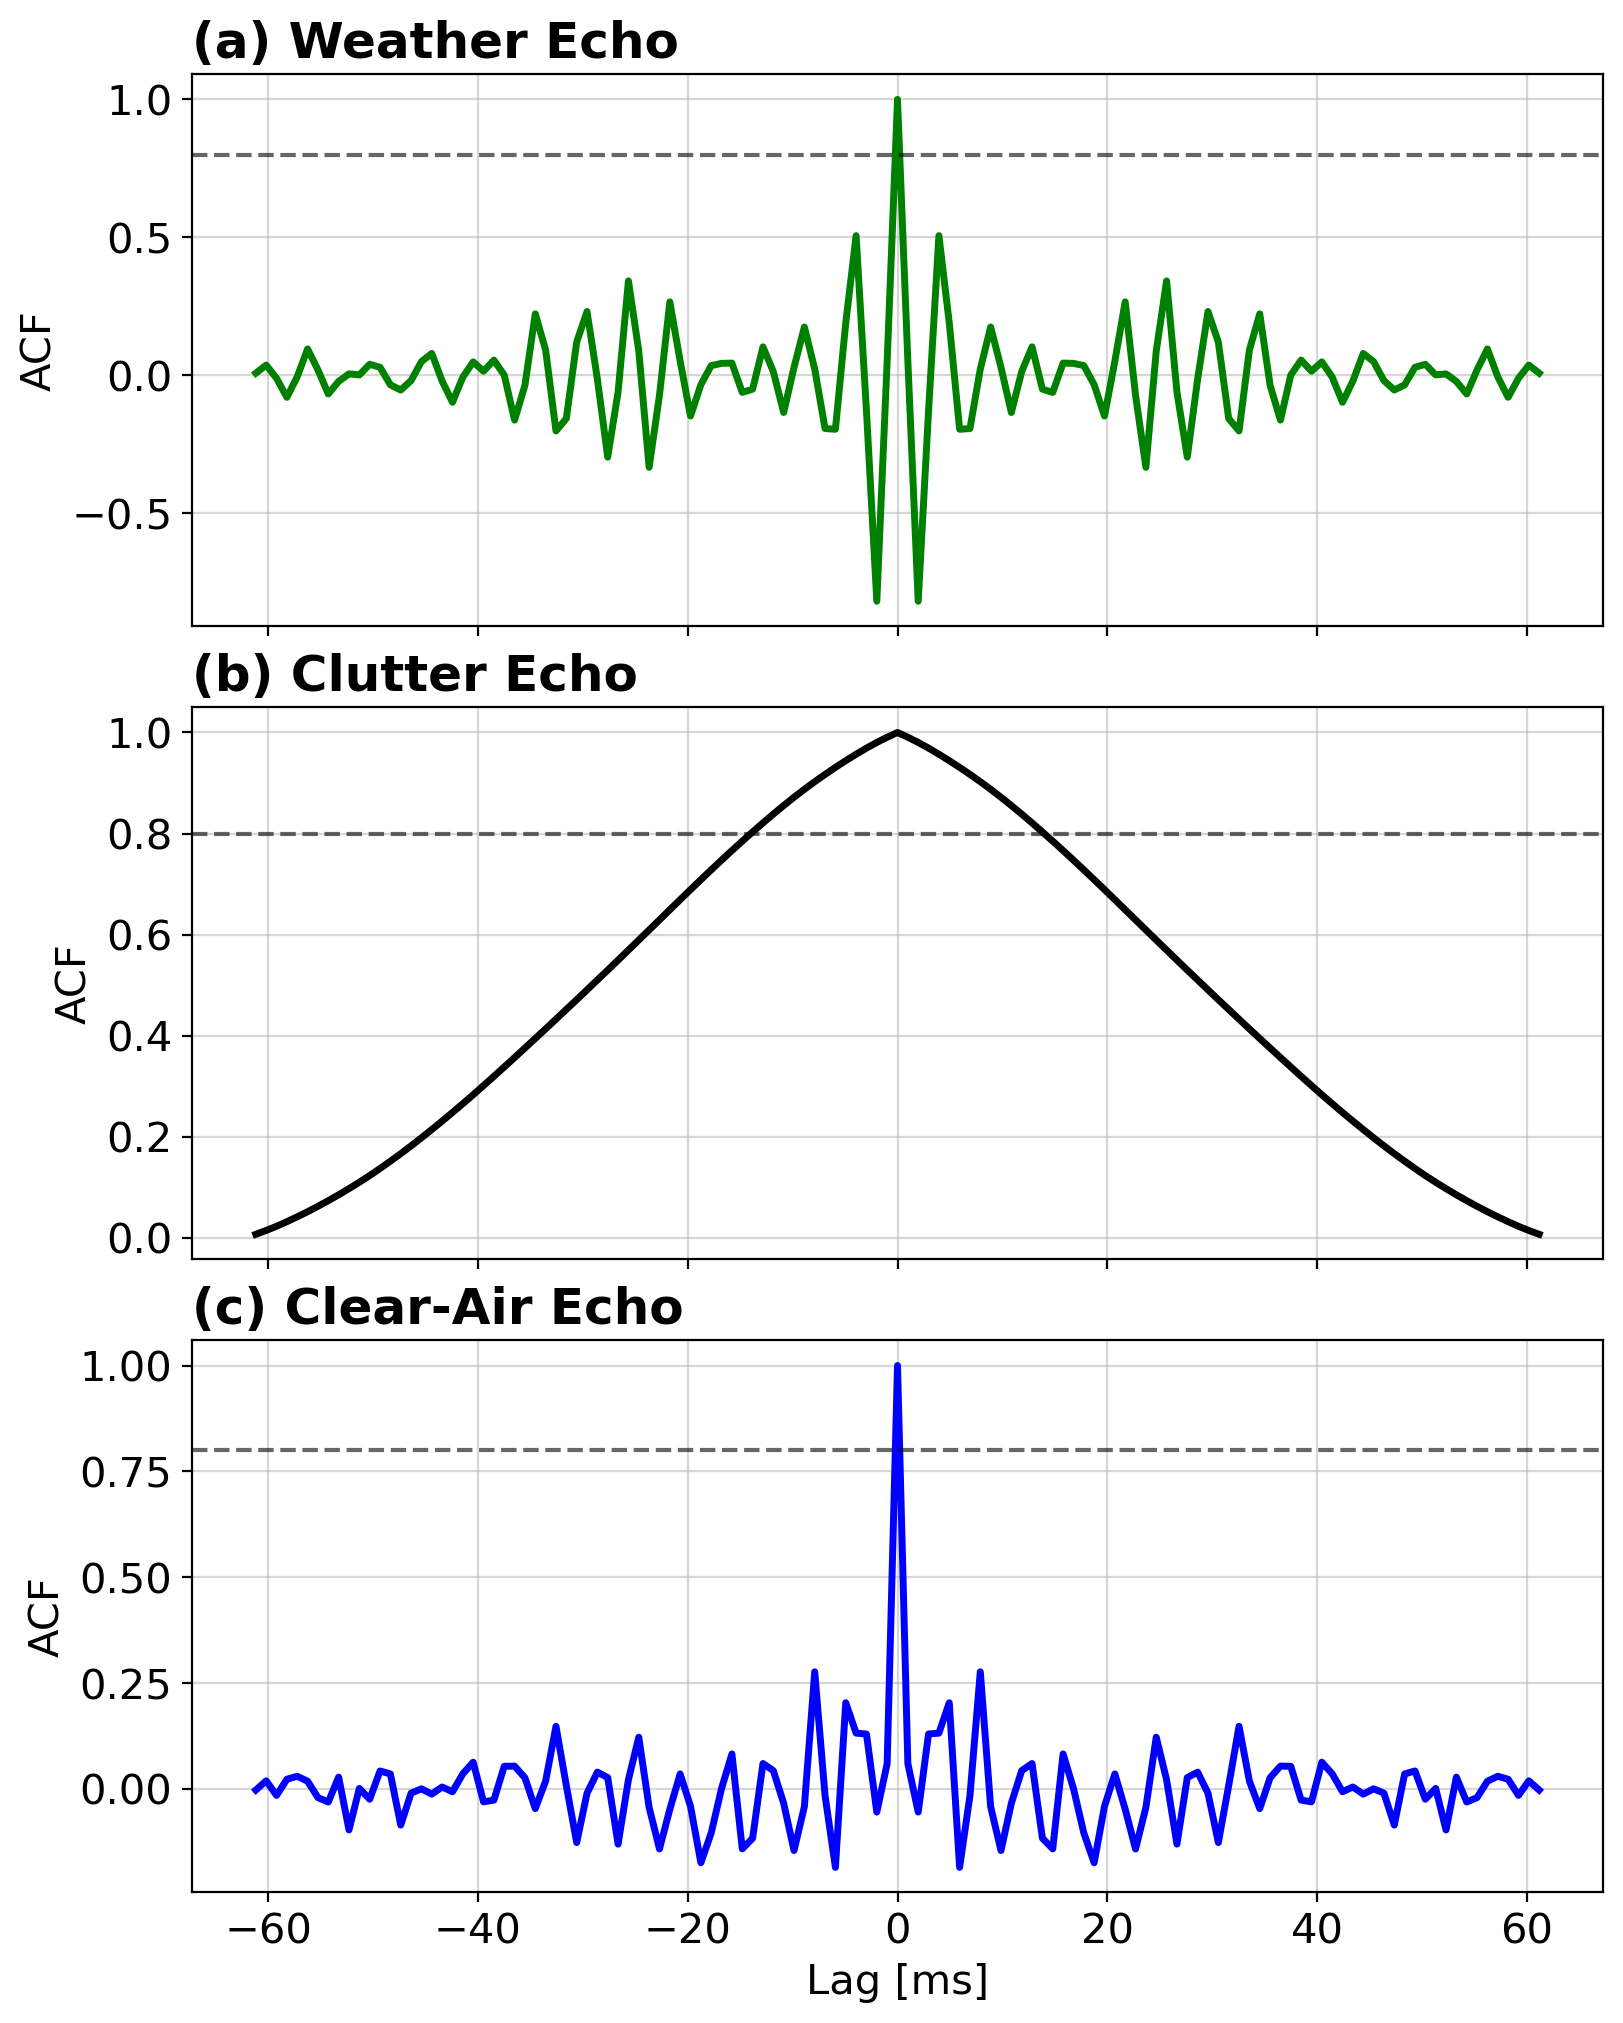

In [10]:
fig, axs = plt.subplots(figsize=(8,10),
                        constrained_layout=True,
                        nrows=3,
                        dpi=200,
                        sharex=True)

# weather
ax = axs[0]
ax.plot(lags*prt*1e3, ACFw_norm,
        c='green',
        lw=2.5)
ax.set_title("(a) Weather Echo", fontweight='bold', loc='left')
# clutter
ax = axs[1]
ax.plot(lags*prt*1e3, ACFc_norm,
        c='black',
        lw=2.5)
ax.set_title("(b) Clutter Echo", fontweight='bold', loc='left')
# clear-air
ax = axs[2]
ax.plot(lags*prt*1e3, ACFca_norm,
        c='blue',
        lw=2.5)
ax.set_title("(c) Clear-Air Echo", fontweight='bold', loc='left')
ax.set_xlabel("Lag [ms]")
for ax in axs:
    ax.grid(alpha=0.5)
    ax.set_ylabel("ACF")
    ax.axhline(y=0.8, c='black', ls='--', alpha=0.6, label='Decorrelation Point')

Compute decorrelation time

In [11]:
thresh = 0.8
pos_mask = lags >= 0
lags_pos = lags[pos_mask]

# weather
ACFw_pos = ACFw_norm[pos_mask]
below_idx = np.where(ACFw_pos < thresh)[0]
decor_time_idx = lags_pos[below_idx[0]]
decor_time_w = lags_pos[decor_time_idx]*prt
# clutter
ACFc_pos = ACFc_norm[pos_mask]
below_idx = np.where(ACFc_pos < thresh)[0]
decor_time_idx = lags_pos[below_idx[0]]
decor_time_c = lags_pos[decor_time_idx]*prt
# clear-air
ACFca_pos = ACFca_norm[pos_mask]
below_idx = np.where(ACFca_pos < thresh)[0]
decor_time_idx = lags_pos[below_idx[0]]
decor_time_ca = lags_pos[decor_time_idx]*prt

In [12]:
print(decor_time_w*1e3, decor_time_c*1e3, decor_time_ca*1e3)

0.9866736450531303 14.800104675796955 0.9866736450531303


### <u>Question 3</u>:

### Plot example scatter diagrams of I + jQ for the weather case only. Given the limited number of pulses in each dwell, it may be necessary to concatenate the signals from several adjacent pixels to get a representative plot. Are the signals correlated? How can you tell from the scatter diagram? It is important to have the same scale on the I and Q axes for comparison

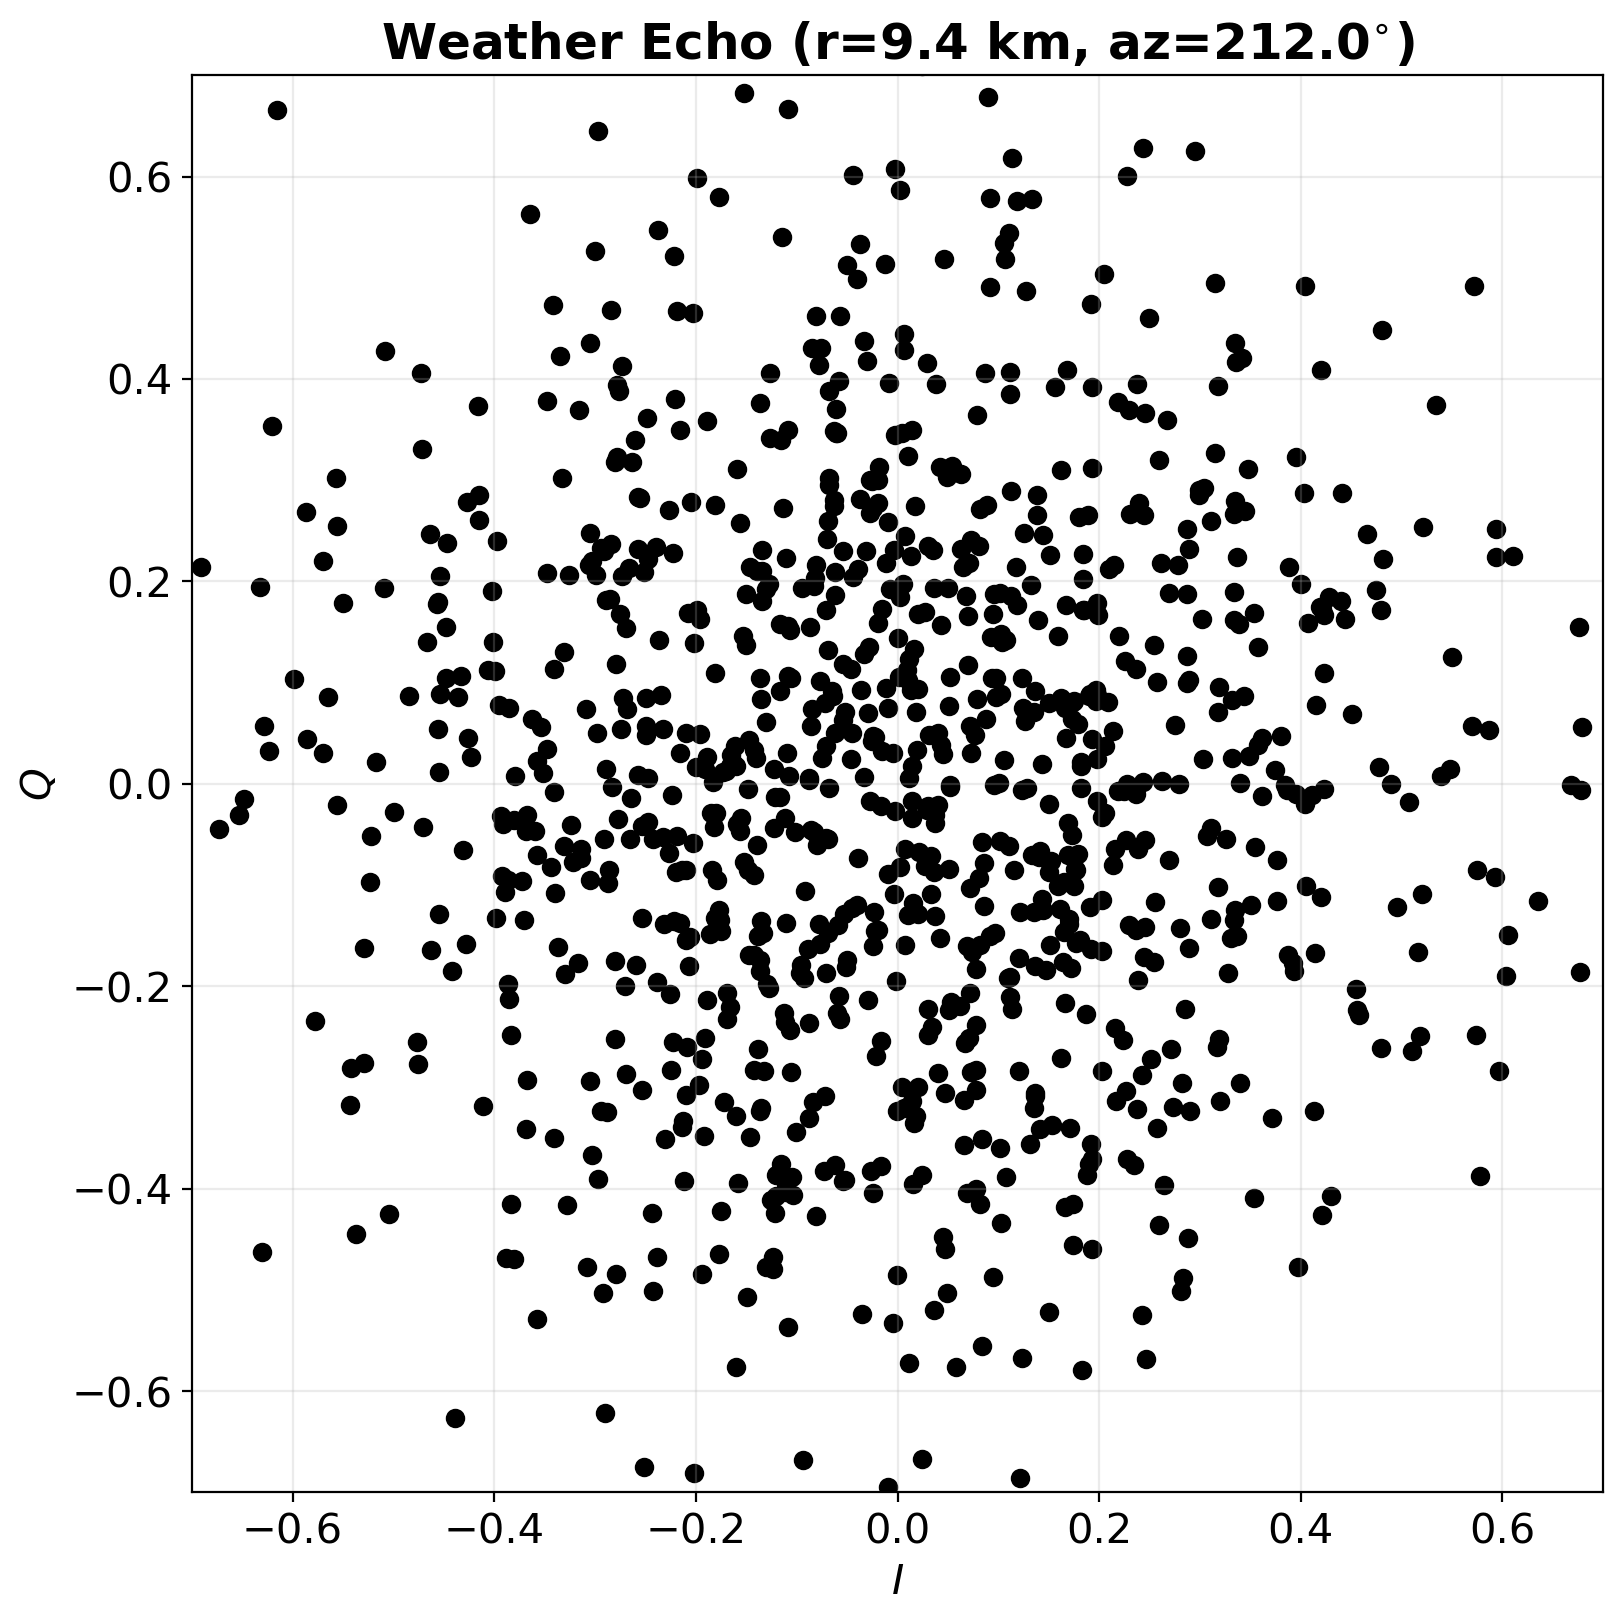

In [13]:
fig, ax = plt.subplots(figsize=(8,8),
                       constrained_layout=True,
                       dpi=200)

# ax.scatter(Iw, Qw, c='black')
ax.scatter(I[azw_idx-2:azw_idx+2, rw_idx-2:rw_idx+2],
           Q[azw_idx-2:azw_idx+2, rw_idx-2:rw_idx+2],
           c='black')

ax.set_title(f"Weather Echo (r={(rw/1e3):.1f} km, az={azw:.1f}$^{{\\circ}}$)",
             fontweight='bold')

ax.set_ylabel("$Q$")
ax.set_ylim(-0.7,0.7)
ax.set_xlabel("$I$")
ax.set_xlim(-0.7,0.7)
ax.grid(alpha=0.25)

### <u>Question 4</u>:

### You will now use the hist command to estimate the probability density functions (pdf) for various products of the radar signal for the weather case only. As we discussed in class, the I and Q signals are assumed to have a Gaussian pdf. Verify this assumption and provide (plot) representative examples

Text(0.0, 1.0, '(a) PDF of the In-Phase Signal')

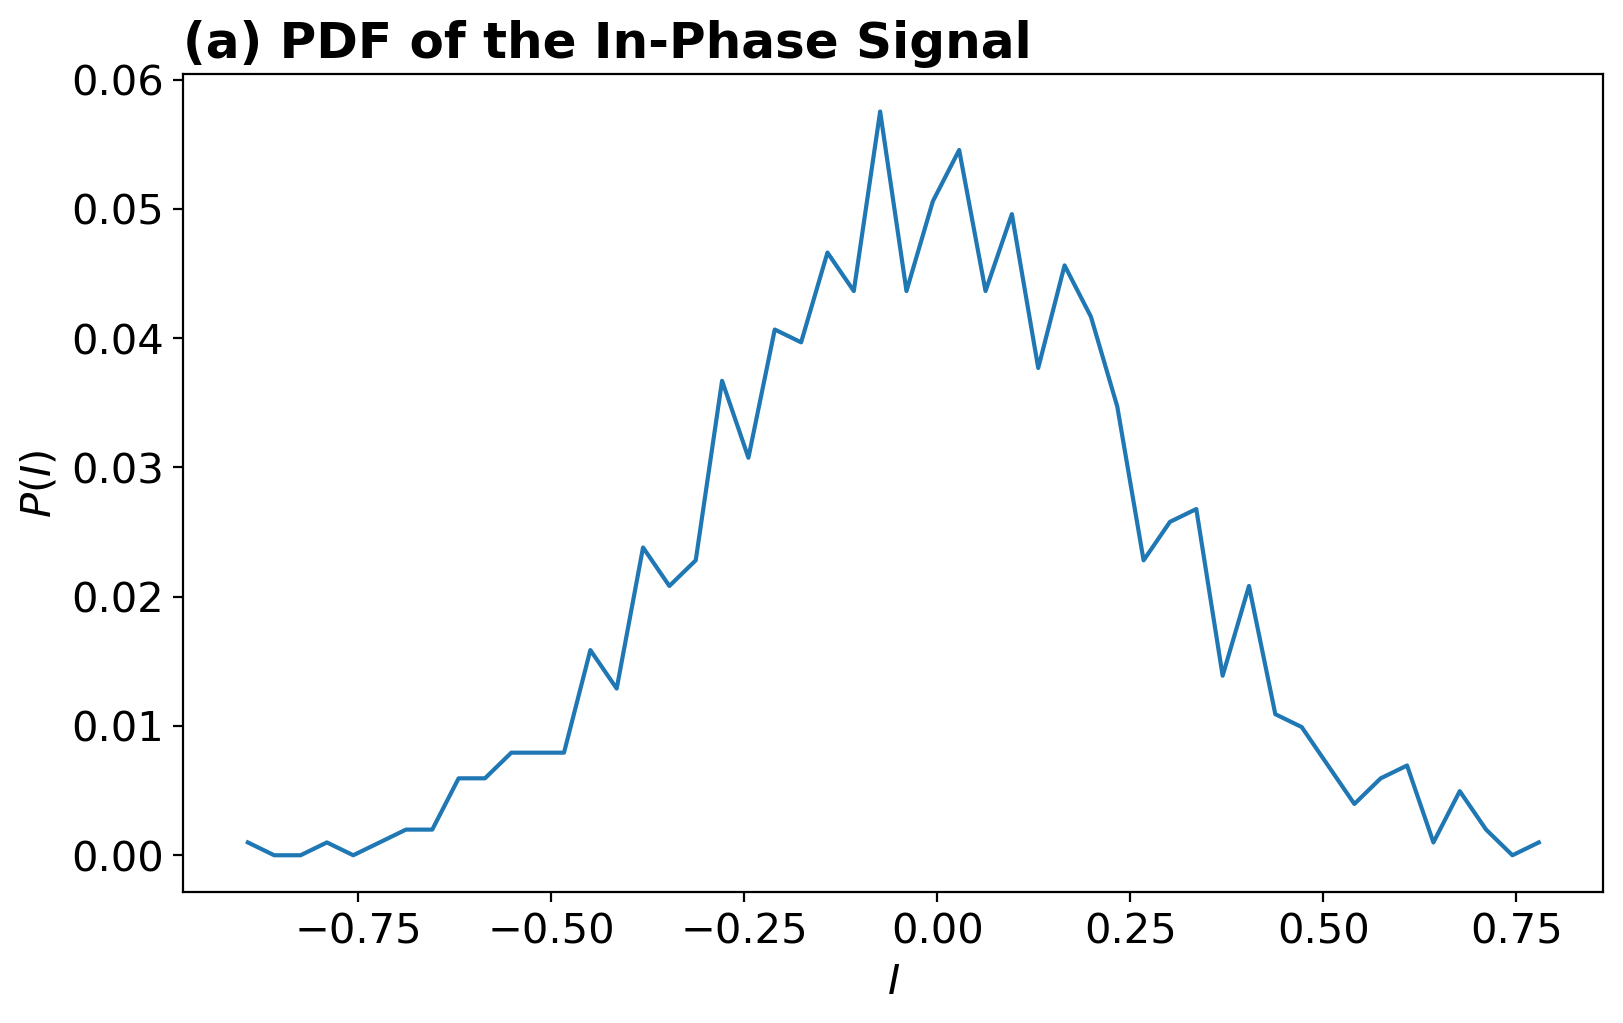

In [14]:
# aggregate multiple gates
I_PDF = I[azw_idx-2:azw_idx+2, rw_idx-2:rw_idx+2]
c, be = np.histogram(I_PDF, bins=50, density=False)
d = c/I_PDF.size
bc = 0.5 * (be[1:] + be[:-1])

fig, ax = plt.subplots(figsize=(8,5),
                       constrained_layout=True,
                       dpi=200)
ax.plot(bc, d)
ax.set_ylabel("$P(I)$")
ax.set_xlabel("$I$")
ax.set_title("(a) PDF of the In-Phase Signal", loc='left', fontweight='bold')

Text(0.0, 1.0, '(b) PDF of the Quadrature Signal')

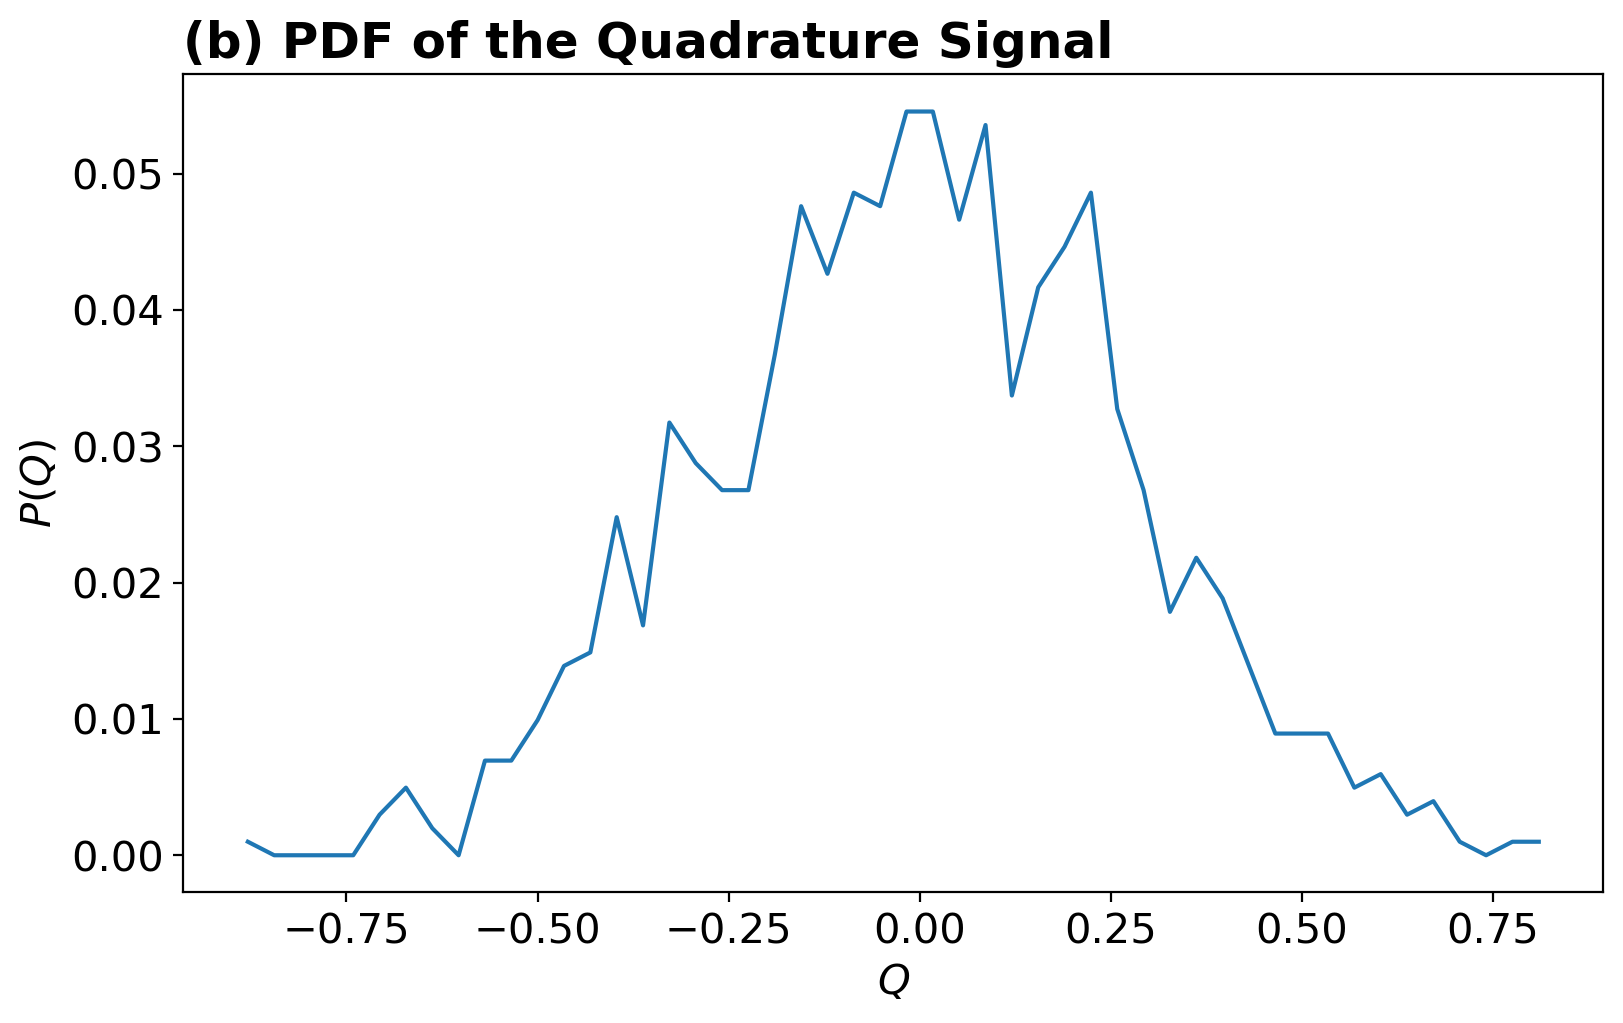

In [15]:
# aggregate multiple gates
Q_PDF = Q[azw_idx-2:azw_idx+2, rw_idx-2:rw_idx+2]
c, be = np.histogram(Q_PDF, bins=50, density=False)
d = c/Q_PDF.size
bc = 0.5 * (be[1:] + be[:-1])

fig, ax = plt.subplots(figsize=(8,5),
                       constrained_layout=True,
                       dpi=200)
ax.plot(bc, d)
ax.set_ylabel("$P(Q)$")
ax.set_xlabel("$Q$")
ax.set_title("(b) PDF of the Quadrature Signal", loc='left', fontweight='bold')

### <u>Question 5</u>:

### Calculate the amplitude |V|, phase γ, and power P = |V|^2 for the weather case only. Estimate and plot the pdfs for each parameter. As you will see in class, amplitude |V|, phase γ, and power P = |V|^2 should have Rayleigh, uniform, and exponential pdfs, respectively. Is this the case? Compare various parts of the observation region

In [16]:
ampw = np.abs(Xh[azw_idx-3:azw_idx+3, rw_idx-3:rw_idx+3])
phiw = np.angle(Xh[azw_idx-3:azw_idx+3, rw_idx-3:rw_idx+3])
poww = np.abs(Xh[azw_idx-3:azw_idx+3, rw_idx-3:rw_idx+3])**2

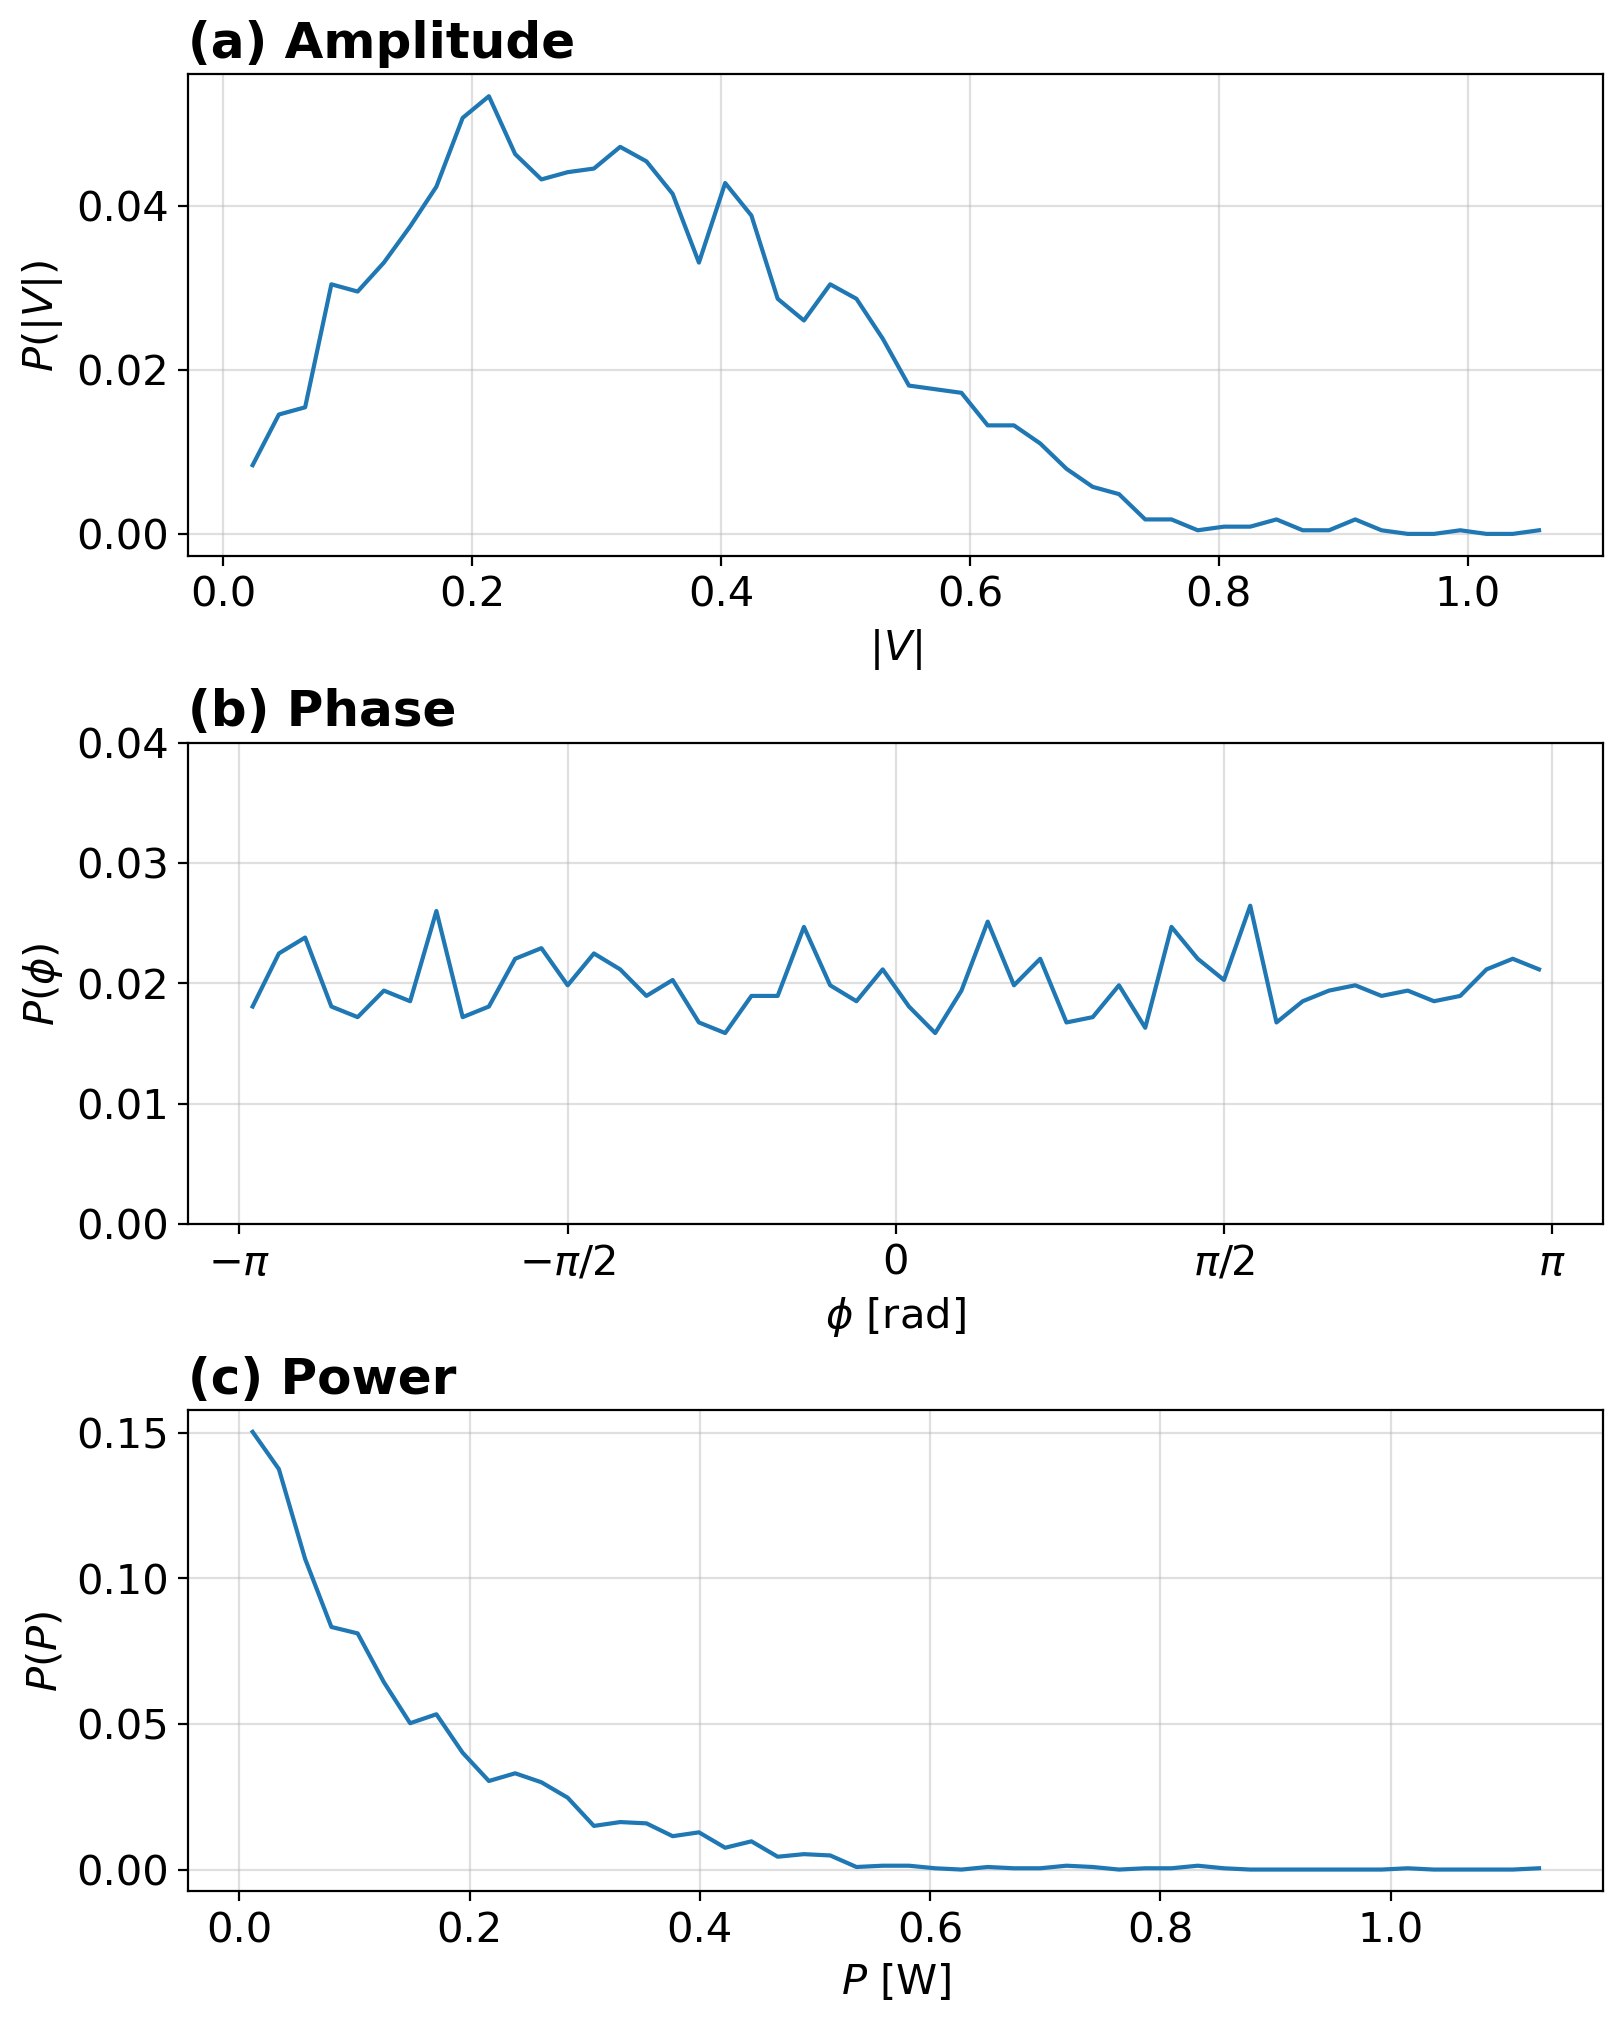

In [17]:
fig, axs = plt.subplots(figsize=(8,10),
                        constrained_layout=True,
                        nrows=3,
                        dpi=200)

# amplitude
c, be = np.histogram(ampw, bins=50, density=False)
d = c/ampw.size
bc = 0.5 * (be[1:] + be[:-1])
ax = axs[0]
ax.plot(bc, d)
ax.set_ylabel("$P(|V|)$")
ax.set_xlabel("$|V|$")
ax.set_title("(a) Amplitude", loc='left', fontweight='bold')

# phase
c, be = np.histogram(phiw, bins=50, density=False)
d = c/phiw.size
bc = 0.5 * (be[1:] + be[:-1])
ax = axs[1]
ax.plot(bc, d)
ax.set_ylabel("$P(\phi)$")
ax.set_xlabel("$\phi$ [rad]")
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels(["$-\pi$", "$-\pi/2$", "0", "$\pi/2$", "$\pi$"])
ax.set_title("(b) Phase", loc='left', fontweight='bold')
ax.set_ylim(0, 0.04)

# amplitude
c, be = np.histogram(poww, bins=50, density=False)
d = c/poww.size
bc = 0.5 * (be[1:] + be[:-1])
ax = axs[2]
ax.plot(bc, d)
ax.set_ylabel("$P(P)$")
ax.set_xlabel("$P$ [W]")
ax.set_title("(c) Power", loc='left', fontweight='bold')

for ax in axs:
    ax.grid(alpha=0.4)

### <u>Question 6</u>:

### Estimate and plot the PSD for the three (3) cases from the first question using the Matlab subroutine periodogramse, then use fftshift to shift lower frequencies to the left and higher frequency to the right. The necessity of the fftshift command is due to the fft algorithm. Can you give a rough estimate of the Doppler frequency and radial velocity based on the PSD? How does your estimate compare to your “hand estimate” from your previous assignment? Which is easier to implement, more accurate, etc.?

#### FFT of I/Q

In [22]:
nfft = num_pulses*1 # no zero padding

# weather
PSDw = np.abs(np.fft.fft(Xhw, n=nfft))**2
PSDw = 10*np.log10(PSDw*(prt/Xhw.size))
PSDw = np.fft.fftshift(PSDw)
# clutter
PSDc = np.abs(np.fft.fft(Xhc, n=nfft))**2
PSDc = 10*np.log10(PSDc*(prt/Xhc.size))
PSDc = np.fft.fftshift(PSDc)
# clear-air
PSDca = np.abs(np.fft.fft(Xhca, n=nfft))**2
PSDca = 10*np.log10(PSDca*(prt/Xhca.size))
PSDca = np.fft.fftshift(PSDca)

# Doppler frequency
f = np.fft.fftfreq(nfft)
fd = f/prt
fd = np.fft.fftshift(fd)
# radial velocity
Vr = (fd*0.1)/-2

# nyquist
nvr = 0.1/(prt*4)
nfd = (2*nvr)/0.1

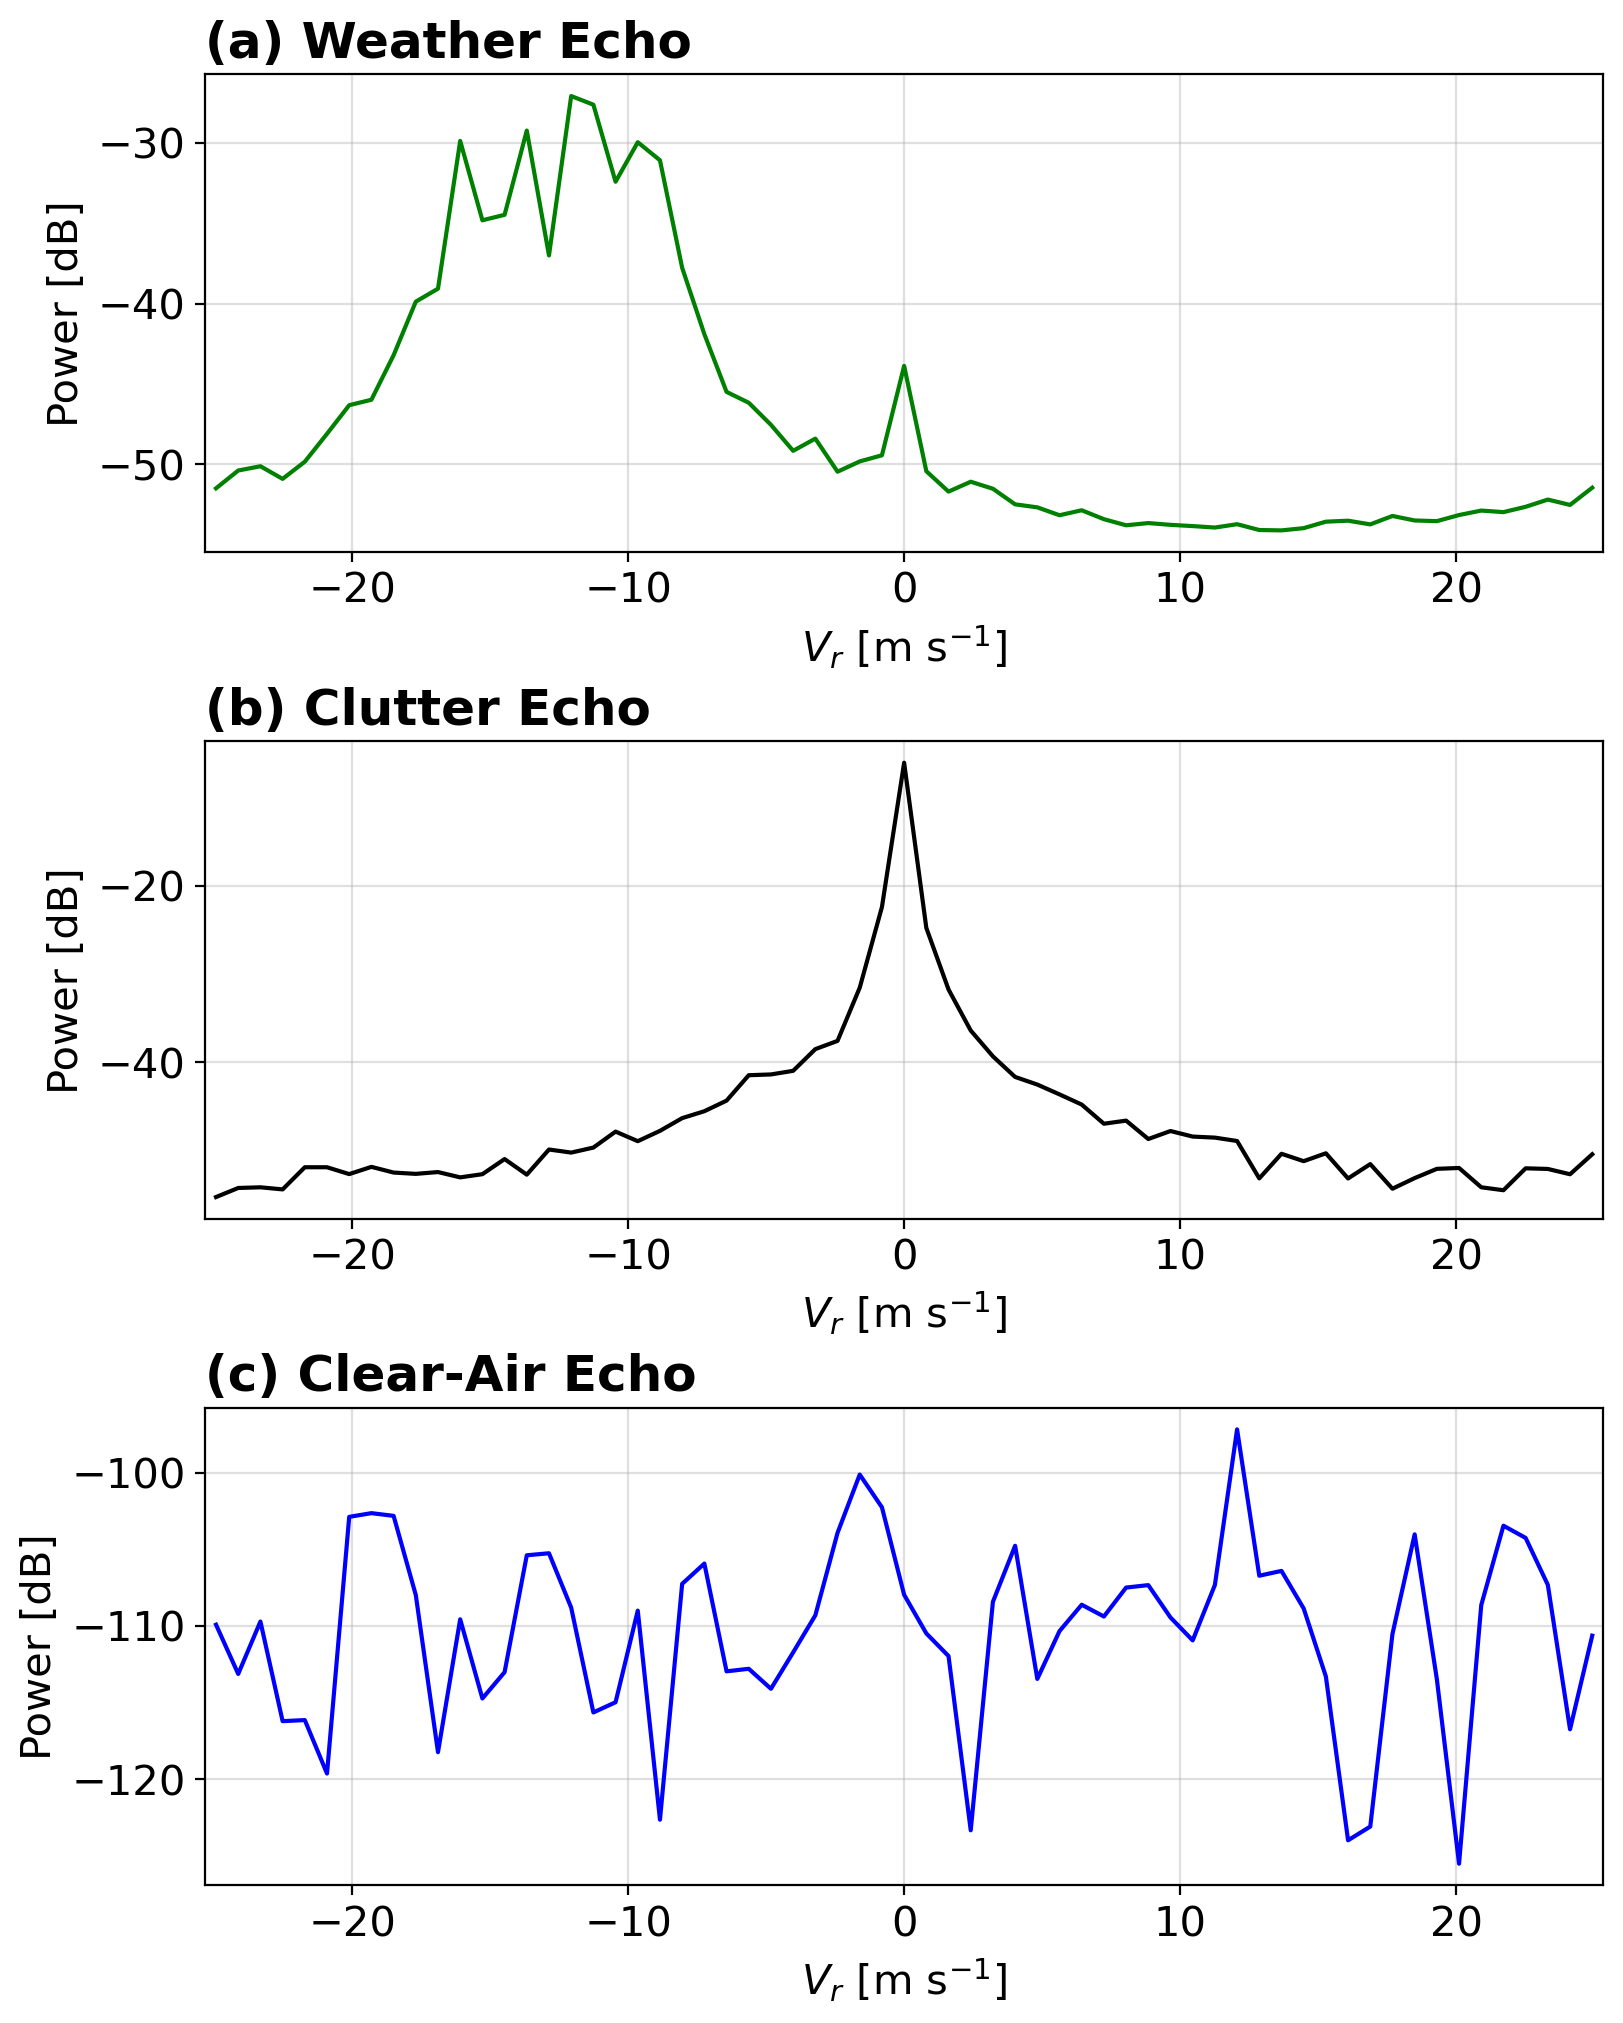

In [23]:
fig, axs = plt.subplots(figsize=(8,10),
                       constrained_layout=True,
                       dpi=200,
                       nrows=3,
                       ncols=1)

# Doppler velocity
ax = axs[0]
ax.plot(Vr, PSDw, label="Weather", c='green')
ax.set_title("(a) Weather Echo", fontweight='bold', loc='left')
ax = axs[1]
ax.plot(Vr, PSDc, label="Clutter", c='black')
ax.set_title("(b) Clutter Echo", fontweight='bold', loc='left')
ax = axs[2]
ax.plot(Vr, PSDca, label="Clear-Air", c='blue')
ax.set_title("(c) Clear-Air Echo", fontweight='bold', loc='left')

# clean up
for ax in axs:
    ax.set_xlabel("$V_r$ [m s$^{-1}$]")
    ax.set_ylabel("Power [dB]")
    ax.set_xlim(-nvr,nvr)
    ax.grid(alpha=0.4)